In [1]:
import pandas as pd

In [ ]:
# ## ----- the directory convention used is based off the google drive organization ------ ##

# check og df

In [30]:
# rheo_df = pd.read_excel("/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/UAFW/UAFW_20260707_rheo.xls")

import pandas as pd

tga_xl = pd.ExcelFile('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/TGA/2026-07-08/2026-07-08-TGA-UAFW.xls',
                    #    sheet_name="Ramp 10.00 °Cmin to 650.00 °C", 
                     #   header=1
                       )
# cols = list(tga_df.columns)
# print(cols)
tga_xl

# print(type(cols))
# sheets = list(tga_df.keys())
sheets = tga_xl.sheet_names
sheets
# data = sheets[1:]
# sheets


['Details', 'Ramp 10.00 °Cmin to 800.00 °C']

# extract data fxn

In [52]:

# if you want a df of the details, use:
# details_df = pd.read_excel("path_to_excel_file", sheet_name = "Details", header = 1)

def extract_data(path): 
    # Read in original file 
    xl = pd.ExcelFile(path) 
    all_sheets = xl.sheet_names 
    print(all_sheets)
    
    data_sheets = all_sheets[1:] 
    df_list = [] 
    
    for sheet in data_sheets: 
        sheet_df = pd.read_excel(path, sheet_name=sheet, header=1) 
        
        # extract the units from the first row of data (index 0)
        units = sheet_df.iloc[0].fillna('').astype(str).tolist()
        
        # combine old column names with the units
        new_columns = []
        for col, unit in zip(sheet_df.columns, units):
            clean_col = col.split('.')[0] if '.' in col else col
            if unit:
                new_columns.append(f"{clean_col} ({unit})")
            else:
                new_columns.append(clean_col)
                
        # assign the new combined names back to the dataframe columns
        sheet_df.columns = new_columns
        
        # drop units row from the data
        sheet_df = sheet_df.drop(index=0).reset_index(drop=True)
        
        # add source sheet column
        sheet_df['Source Sheet'] = sheet 
        df_list.append(sheet_df) 
        
    # Vertically stack all the sheets together into one final df 
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # convert to float
    # errors='coerce' turns any unconvertible text or bad data into NaN safely
    for col in combined_df.columns:
        if col != 'Source Sheet':
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # make sure source sheet is last column in final df
    cols = [col for col in combined_df.columns if col != 'Source Sheet'] + ['Source Sheet']
    combined_df = combined_df[cols]
    
    return combined_df

data_df = extract_data('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/TGA/2026-07-13/2026-07-13-TGA-UAFW.xls')
data_df[100:]

['Details', 'Ramp 10.00 °Cmin to 650.00 °C', 'Equilibrate 30.00 °C']


,Time (min),Temperature (°C),Weight (mg),Weight (%),Deriv (% / °C),Source Sheet
100,1.67,35.35,7.061,96.595,-0.471670,Ramp 10.00 °Cmin to 650.00 °C
101,1.69,35.52,7.056,96.527,-0.473274,Ramp 10.00 °Cmin to 650.00 °C
102,1.71,35.69,7.051,96.459,-0.474875,Ramp 10.00 °Cmin to 650.00 °C
103,1.72,35.86,7.046,96.389,-0.476471,Ramp 10.00 °Cmin to 650.00 °C
104,1.74,36.03,7.041,96.318,-0.478066,Ramp 10.00 °Cmin to 650.00 °C
...,...,...,...,...,...,...
4724,78.74,43.45,-0.006,-0.076,0.000618,Equilibrate 30.00 °C
4725,78.76,43.38,-0.006,-0.076,0.000619,Equilibrate 30.00 °C
4726,78.77,43.32,-0.006,-0.076,0.000619,Equilibrate 30.00 °C
4727,78.79,43.25,-0.006,-0.076,0.000619,Equilibrate 30.00 °C


# TGA plot

## single plot

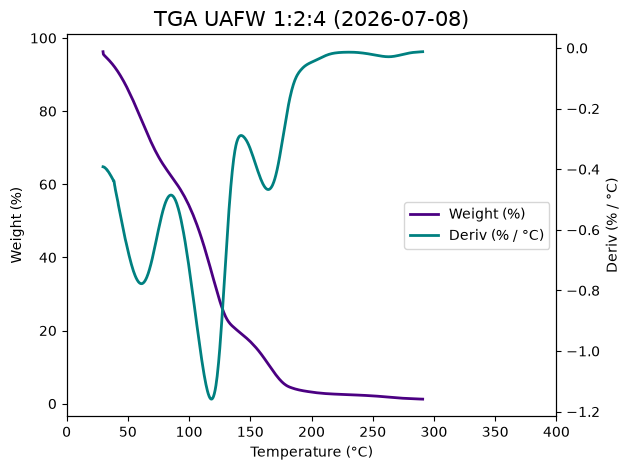

In [33]:
import matplotlib.pyplot as plt

data_cols = list(data_df.columns)

y1 = "indigo"
y2 = "teal"

fig, ax1 = plt.subplots()

weight_pct = ax1.plot(data_df[data_cols[1]], data_df[data_cols[3]], color = y1, lw = 2, label = data_cols[3])
ax1.set_xlabel(data_cols[1])
ax1.set_ylabel(data_cols[3])
ax1.tick_params(axis='y')
ax1.set_xlim(0,400)

ax2 = ax1.twinx()

deriv = ax2.plot(data_df[data_cols[1]], data_df[data_cols[4]], color = y2, lw = 2, label = data_cols[4])
ax2.set_ylabel(data_cols[4])
ax2.tick_params(axis = 'y')

plt.title("TGA UAFW 1:2:4 (2026-07-08)", fontsize=15)
plt.legend(loc = "center right", handles = [weight_pct[0], 
                                            deriv[0]
                                            ])
plt.tight_layout()
plt.show()


## multiplot

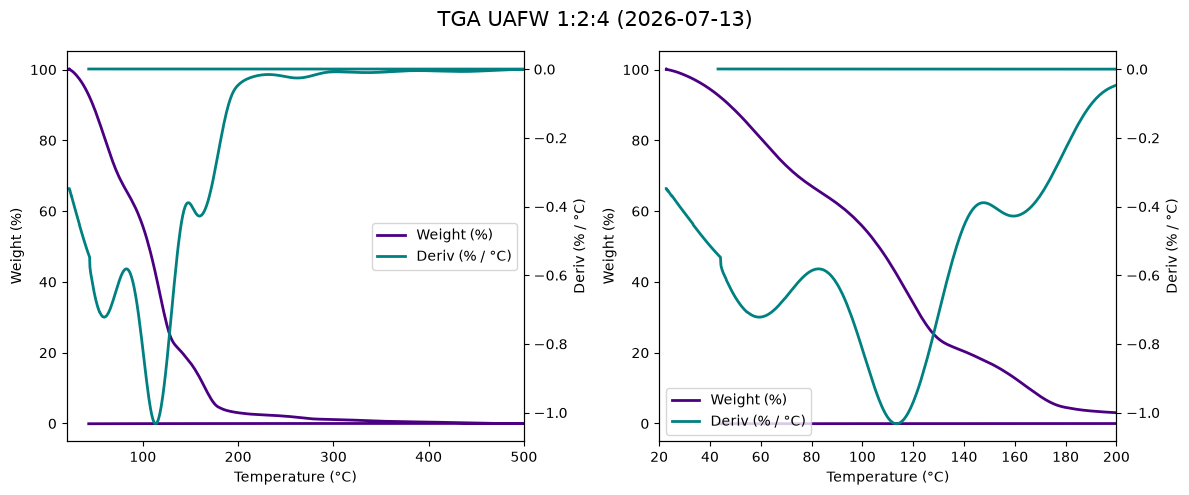

In [56]:
import matplotlib.pyplot as plt

data_cols = list(data_df.columns)

y1 = "indigo"
y2 = "teal"

fig, (ax1, ax2) = plt.subplots(1 ,2, figsize = (12,5))

weight_pct = ax1.plot(data_df[data_cols[1]], data_df[data_cols[3]], color = y1, lw = 2, label = data_cols[3])
ax1.set_xlabel(data_cols[1])
ax1.set_ylabel(data_cols[3])
ax1.tick_params(axis='y')
ax1.set_xlim(20,500)

ax1_twin = ax1.twinx()

deriv = ax1_twin.plot(data_df[data_cols[1]], data_df[data_cols[4]], color = y2, lw = 2, label = data_cols[4])
ax1_twin.set_ylabel(data_cols[4])
ax1_twin.tick_params(axis = 'y')
ax1.legend(loc = "center right", handles = [weight_pct[0], 
                                            deriv[0],]
                                            )

# subplot 2
weight_pct2 = ax2.plot(data_df[data_cols[1]], data_df[data_cols[3]], color = y1, lw = 2, label = data_cols[3])
ax2.set_xlabel(data_cols[1])
ax2.set_ylabel(data_cols[3])
ax2.tick_params(axis='y')
ax2.set_xlim(20,200)

ax2_twin = ax2.twinx()

deriv2 = ax2_twin.plot(data_df[data_cols[1]], data_df[data_cols[4]], color = y2, lw = 2, label = data_cols[4])
ax2_twin.set_ylabel(data_cols[4])
ax2_twin.tick_params(axis = 'y')
ax2.legend(loc = "lower left", handles = [weight_pct2[0], 
                                            deriv2[0]]
                                            )

plt.suptitle("TGA UAFW 1:2:4 (2026-07-13)", fontsize=15)
# plt.legend()
plt.tight_layout()
plt.show()
